在SOFA环境下对Liver的全局变形控制

上游代码 -> `LiverGlobalControl.py` & `LiverGlobalControl2.py`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator
from matplotlib.gridspec import GridSpec
from matplotlib.collections import LineCollection
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from matplotlib.colors import Normalize
import matplotlib.cm as cm
import matplotlib.font_manager as fm
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from mpl_toolkits.mplot3d import Axes3D

# 设置全局字体为 Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = 'Times New Roman'

In [33]:
POINTS_NUM:int = 1
num:int = 1

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
dot_sofa_np = np.loadtxt(f'dots_sofa_list{num}.csv', delimiter=',')
rob_mov_np = np.loadtxt(f'rob_movement_list{num}.csv', delimiter=',')
sofa_contact_pos = np.loadtxt(f'sofa_contact_pos_list{num}.csv', delimiter=',')

In [82]:
def plot_loss(loss_np, plot_step_num):
    # plot_step_num = loss_np.shape[0]
    fig = plt.figure(figsize=(9, 3), dpi=100)
    gs = GridSpec(1, 1, figure=fig)

    step_num = loss_np.shape[0]
    axs_loss = fig.add_subplot(gs[0, :])
    axs_loss.plot(np.sum(loss_np[:plot_step_num], axis=1), marker='.', linestyle='-', linewidth=2, color='black')
    axs_loss.set_title('Loss Curve', fontsize=16, fontname='Times New Roman')
    axs_loss.set_xlabel('Time Step', fontsize=14, fontname='Times New Roman')
    axs_loss.set_ylabel('Loss', fontsize=14, fontname='Times New Roman')
    axs_loss.set_xlim([-1, plot_step_num])
    axs_loss.xaxis.set_major_locator(MultipleLocator(10))
    axs_loss.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
    axs_loss.grid(True)

---
学习率为8.e1，学习率太大了，导致震荡

1.6249e-06


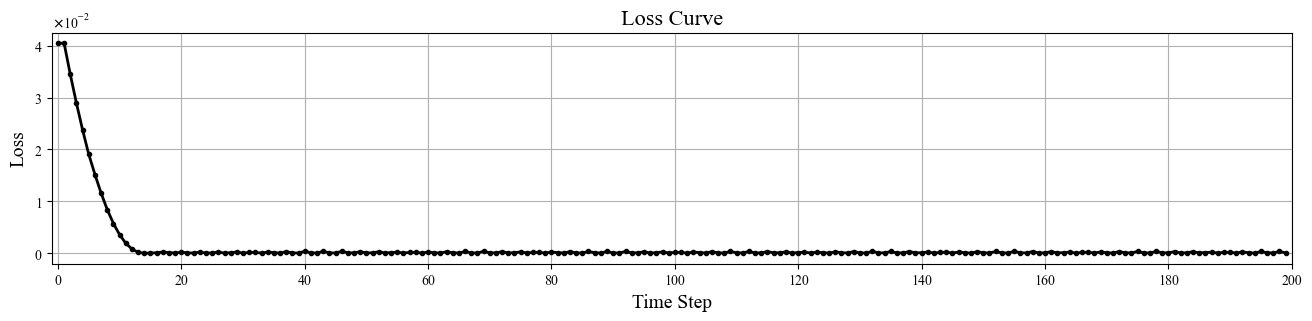

In [34]:
plot_loss(loss_np)
loss_sum = np.sum(loss_np[:], axis=1)
print(np.max(np.abs(loss_np[-1,:])))

In [68]:
def plot_traj(contact_traj, plot_step_num):
    fig = plt.figure(figsize=(8, 6), dpi=100)
    gs = GridSpec(1, 1, figure=fig)
    # plot_step_num = 100

    # 选择点的索引
    indices = np.arange(len(contact_traj[:plot_step_num,0]))

    # 计算颜色渐变
    t = np.linspace(0, 1, len(contact_traj[:plot_step_num,0]))  # 颜色映射的变量，假设是时间
    norm = plt.Normalize(t.min(), t.max())
    colors = cm.viridis(norm(t))  # 使用 viridis 颜色映射
    colors = plt.cm.plasma(norm(t))

    # 创建 3D 坐标点
    rob_pose_xyz = np.stack([contact_traj[:plot_step_num,0][indices], contact_traj[:plot_step_num,1][indices], contact_traj[:plot_step_num,2][indices]], axis=1).reshape(-1, 1, 3)

    # 创建线段（每一段是连续的两个点之间的线段）
    segments = np.concatenate([rob_pose_xyz[:-1], rob_pose_xyz[1:]], axis=1)

    # 使用 Line3DCollection 绘制具有渐变色的轨迹线
    lc = Line3DCollection(segments, colors=colors, linewidth=2)

    ax_traj = fig.add_subplot(gs[0, 0], projection='3d')
    ax_traj.add_collection(lc, autolim=True)

    ax_traj.scatter(contact_traj[0,0], contact_traj[0,1], contact_traj[0,2], c='blue', s=25, label='Initial Position')
    ax_traj.scatter(contact_traj[0,0]+0.025, contact_traj[0,1], contact_traj[0,2], c='red', marker='*', s=25, label='Desired Position')

    ax_traj.set_xlim([np.min(contact_traj[:plot_step_num,0]), np.max(contact_traj[:plot_step_num,0])])
    ax_traj.set_ylim([np.min(contact_traj[:plot_step_num,1]), np.max(contact_traj[:plot_step_num,1])])
    ax_traj.set_zlim([np.min(contact_traj[:plot_step_num,2]), np.max(contact_traj[:plot_step_num,2])])

    ax_traj.set_xlabel('X', fontsize=14, fontname='Times New Roman')
    ax_traj.set_ylabel('Y', fontsize=14, fontname='Times New Roman')
    ax_traj.set_zlabel('Z', fontsize=14, fontname='Times New Roman')

    ax_traj.set_title('Robot Tool Trajectory', fontsize=16, fontname='Times New Roman')
    ax_traj.set_aspect('equal', 'datalim')
    ax_traj.legend(fontsize=12, loc='upper right', bbox_to_anchor=(0.95, 0.8))

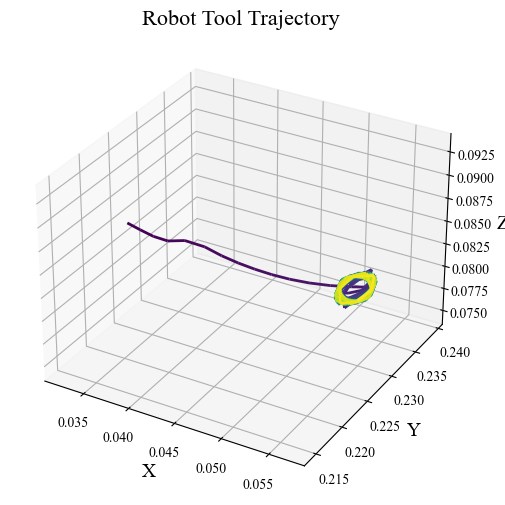

In [35]:
plot_traj(sofa_contact_pos)

---
学习率调整为1.e1

In [37]:
POINTS_NUM:int = 1
num:int = 2

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
dot_sofa_np = np.loadtxt(f'dots_sofa_list{num}.csv', delimiter=',')
rob_mov_np = np.loadtxt(f'rob_movement_list{num}.csv', delimiter=',')
sofa_contact_pos = np.loadtxt(f'sofa_contact_pos_list{num}.csv', delimiter=',')

6.1e-09


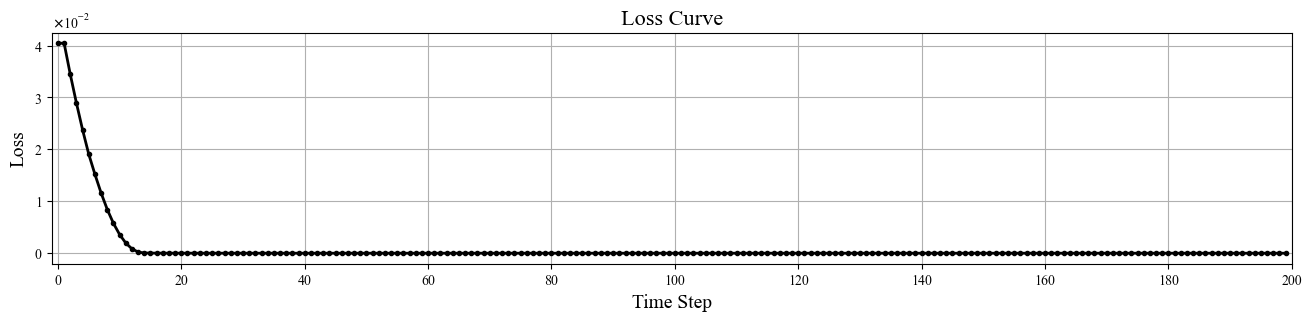

In [38]:
plot_loss(loss_np)
loss_sum = np.sum(loss_np[:], axis=1)
print(np.max(np.abs(loss_np[-1,:])))

Tool Init pos: [0.0311819 0.226972  0.08386  ]; Tool Final pos: [0.05612901 0.22694517 0.08386795]


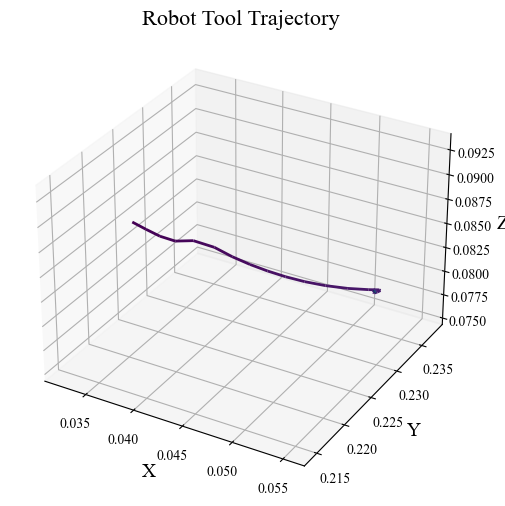

In [39]:
plot_traj(sofa_contact_pos)
print(f"Tool Init pos: {sofa_contact_pos[0]}; Tool Final pos: {sofa_contact_pos[-1]}")

---
学习率为`3.e0`，最大动作由`2.e-3`改为`6.e-4`.并且进行降采样得到的41个marker点，网格简化来源于`liver_surface_simplify3.obj`

In [2]:
num:int = 3

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
dot_sofa_np = np.loadtxt(f'dots_sofa_list{num}.csv', delimiter=',')
rob_mov_np = np.loadtxt(f'rob_movement_list{num}.csv', delimiter=',')
sofa_contact_pos = np.loadtxt(f'sofa_contact_pos_list{num}.csv', delimiter=',')

4.3e-09


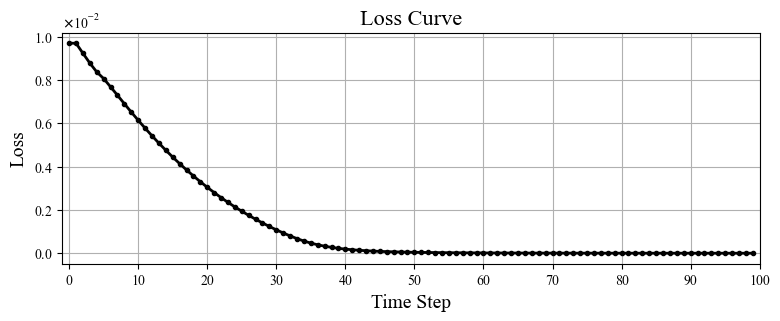

In [86]:
plot_loss(loss_np, 100)
loss_sum = np.sum(loss_np[:], axis=1)
print(np.max(np.abs(loss_np[-1,:])))

Tool Init pos: [0.0311819 0.226972  0.08386  ]; Tool Final pos: [0.05612895 0.2269606  0.08386929]
Total action: [ 2.49470481e-02 -1.13997000e-05  9.28730000e-06]


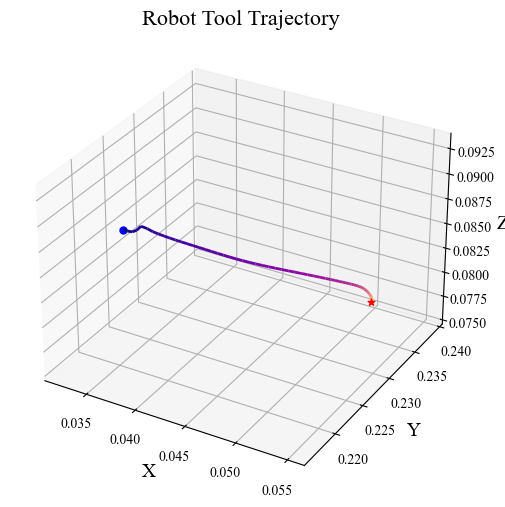

In [87]:
plot_traj(sofa_contact_pos, 100)
print(f"Tool Init pos: {sofa_contact_pos[0]}; Tool Final pos: {sofa_contact_pos[-1]}")
print(f"Total action: {sofa_contact_pos[-1] - sofa_contact_pos[0]}")

---
用于论文绘图

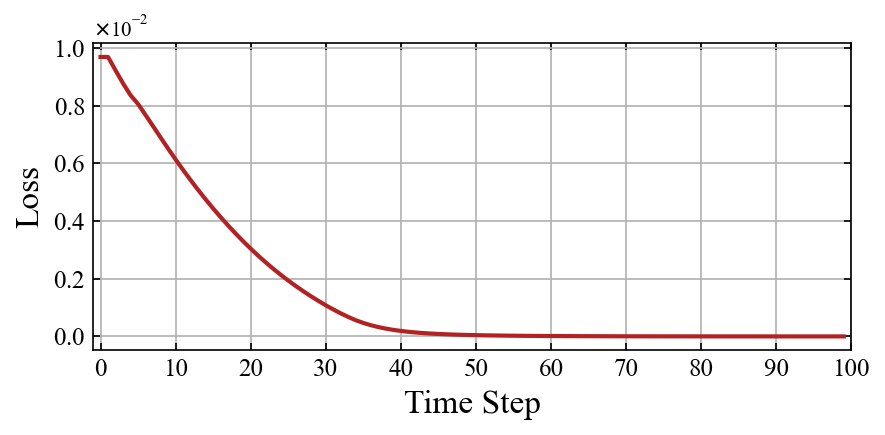

In [24]:
fig = plt.figure(figsize=(6, 3), dpi=150)
gs = GridSpec(1, 1, figure=fig)
plot_step_num = 100

step_num = loss_np.shape[0]
axs_loss = fig.add_subplot(gs[0, :])
axs_loss.plot(np.sum(loss_np[:plot_step_num], axis=1), marker='', linestyle='-', linewidth=2, color='firebrick')
# axs_loss.set_title('Loss Curve', fontsize=16, fontname='Times New Roman')
axs_loss.set_xlabel('Time Step', fontsize=16, fontname='Times New Roman')
axs_loss.set_ylabel('Loss', fontsize=16, fontname='Times New Roman')
axs_loss.set_xlim([-1, plot_step_num])
axs_loss.xaxis.set_major_locator(MultipleLocator(10))
axs_loss.ticklabel_format(axis='y', style='sci', scilimits=(-1, 1), useLocale=False, useMathText=True)
axs_loss.tick_params(axis='both', which='major', labelsize=12, direction='in', top=True, right=True)
axs_loss.grid(True)

fig.tight_layout()
fig.savefig('liver-global-loss.svg', transparent=True, dpi=300, bbox_inches='tight')

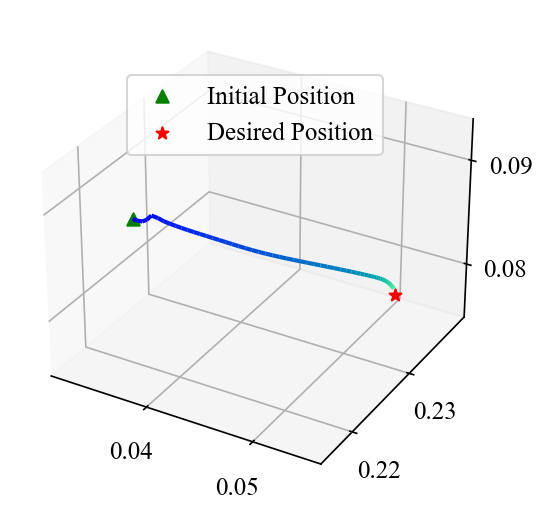

In [23]:
fig = plt.figure(figsize=(4, 3.5), dpi=150)
gs = GridSpec(1, 1, figure=fig)
plot_step_num = 65
contact_traj = sofa_contact_pos

# 选择点的索引
indices = np.arange(len(contact_traj[:plot_step_num,0]))

# 计算颜色渐变
t = np.linspace(0, 1, len(contact_traj[:plot_step_num,0]))  # 颜色映射的变量，假设是时间
norm = plt.Normalize(t.min(), t.max())
colors = cm.winter(norm(t))  # 使用 viridis 颜色映射
# colors = plt.cm.plasma(norm(t))

# 创建 3D 坐标点
rob_pose_xyz = np.stack([contact_traj[:plot_step_num,0][indices], contact_traj[:plot_step_num,1][indices], contact_traj[:plot_step_num,2][indices]], axis=1).reshape(-1, 1, 3)

# 创建线段（每一段是连续的两个点之间的线段）
segments = np.concatenate([rob_pose_xyz[:-1], rob_pose_xyz[1:]], axis=1)

# 使用 Line3DCollection 绘制具有渐变色的轨迹线
lc = Line3DCollection(segments, colors=colors, linewidth=2)

ax_traj = fig.add_subplot(gs[0, 0], projection='3d')
ax_traj.add_collection(lc, autolim=True)

ax_traj.scatter(contact_traj[0,0], contact_traj[0,1], contact_traj[0,2], c='green', marker='^', s=35, label='Initial Position')
ax_traj.scatter(contact_traj[0,0]+0.025, contact_traj[0,1], contact_traj[0,2], c='red', marker='*', s=35, label='Desired Position')

ax_traj.set_xlim([np.min(contact_traj[:plot_step_num,0]), np.max(contact_traj[:plot_step_num,0])])
ax_traj.set_ylim([np.min(contact_traj[:plot_step_num,1]), np.max(contact_traj[:plot_step_num,1])])
ax_traj.set_zlim([np.min(contact_traj[:plot_step_num,2]), np.max(contact_traj[:plot_step_num,2])])

# ax_traj.set_xlabel('X', fontsize=14, fontname='Times New Roman')
# ax_traj.set_ylabel('Y', fontsize=14, fontname='Times New Roman')
# ax_traj.set_zlabel('Z', fontsize=14, fontname='Times New Roman')
ax_traj.xaxis.set_major_locator(MultipleLocator(0.01))
ax_traj.yaxis.set_major_locator(MultipleLocator(0.01))
ax_traj.zaxis.set_major_locator(MultipleLocator(0.01))

# ax_traj.set_title('Robot Tool Trajectory', fontsize=16, fontname='Times New Roman')
ax_traj.set_aspect('equal', 'datalim')
ax_traj.tick_params(axis='both', which='major', labelsize=12)
ax_traj.legend(fontsize=12, loc='upper center', bbox_to_anchor=(0.5, 0.9), ncol=1)

fig.tight_layout()
fig.savefig('liver-global-traj.svg', transparent=True, dpi=300, bbox_inches='tight')